<a href="https://colab.research.google.com/github/TrevorGankarch/PdM-Using-AI-and-Machine-Learning/blob/main/Pdm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


MODEL PERFORMANCE
-----------------
Accuracy : 1.0
ROC AUC  : 1.0


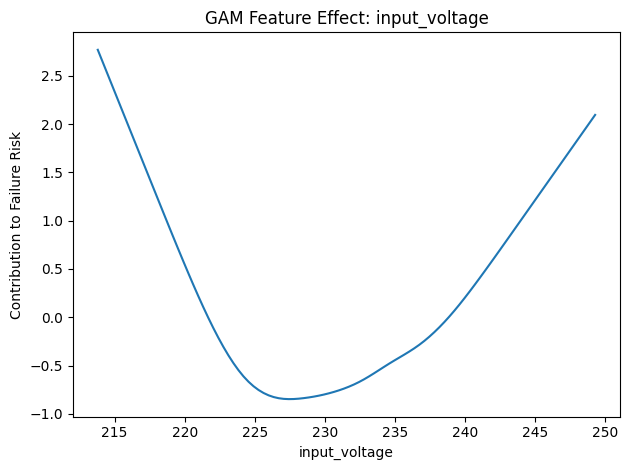

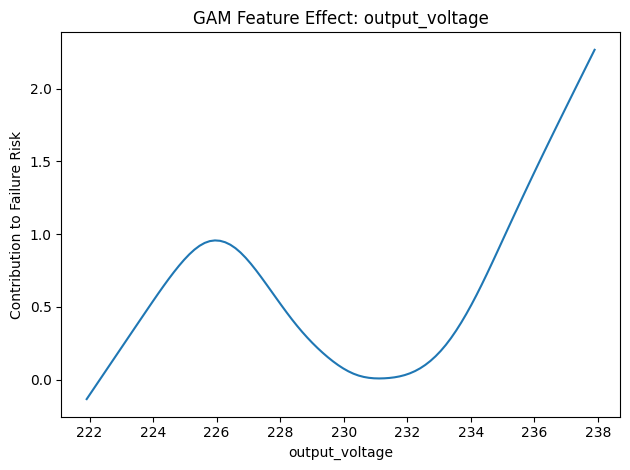

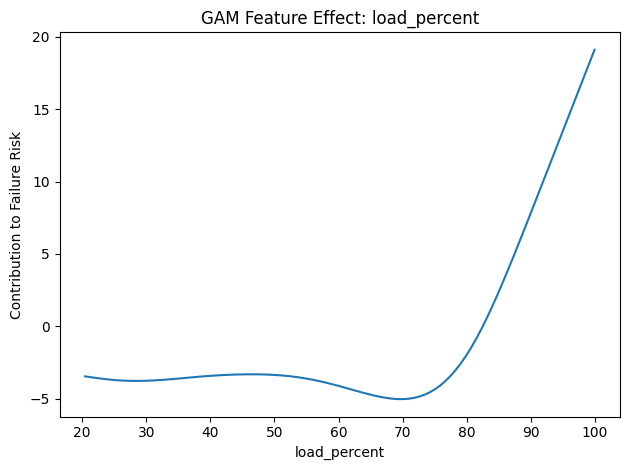

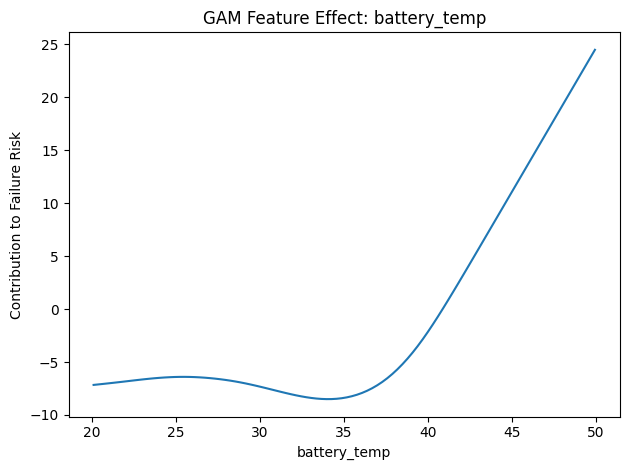

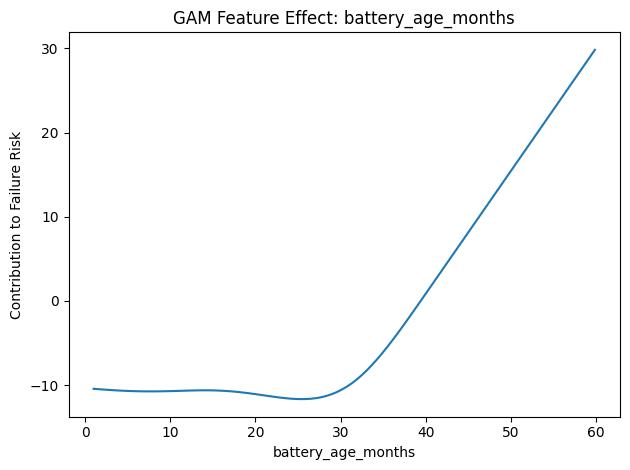

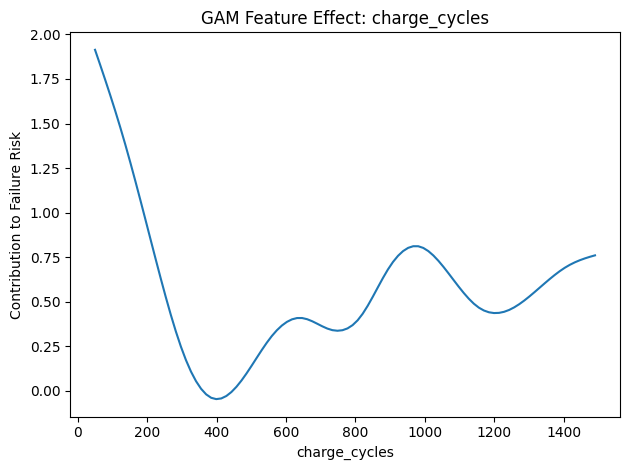

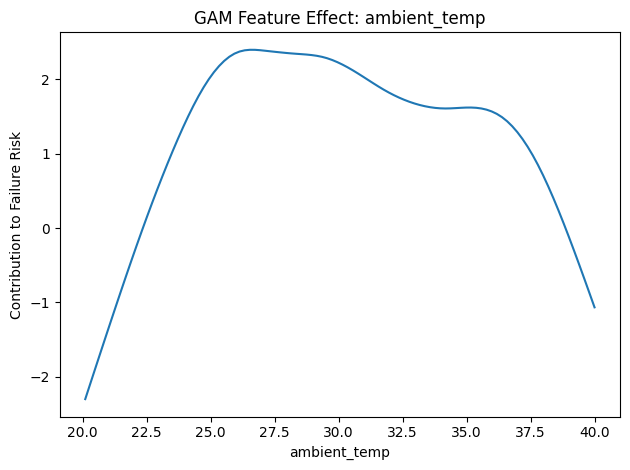

ExactExplainer explainer: 101it [00:19,  3.26it/s]


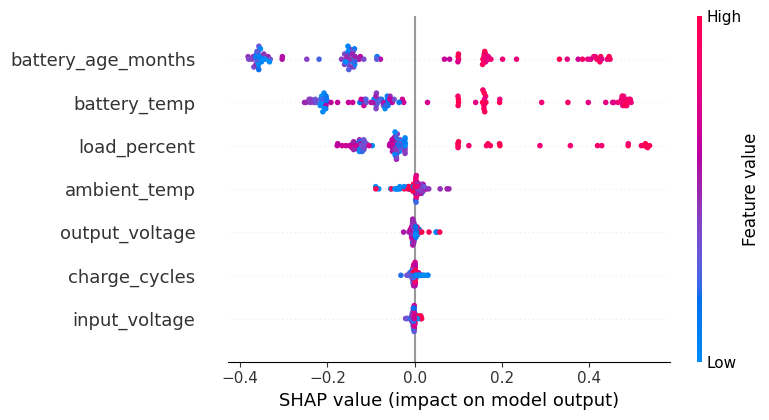


SAMPLE OUTPUT
-------------
     input_voltage  output_voltage  load_percent  battery_temp  \
203     235.269010      225.774616     89.066692     28.465612   
477     231.556251      222.728362     96.426775     39.566728   
458     227.231753      231.709302     98.069900     46.369367   
496     224.813769      235.393060     60.977754     26.209777   
474     238.224839      228.661450     56.755741     23.126744   

     battery_age_months  charge_cycles  ambient_temp  failure_probability  \
203           25.047468    1313.550350     34.748522             0.993206   
477           28.120227     826.702069     34.660002             1.000000   
458           55.131665     538.949535     25.432664             1.000000   
496           34.602847     614.637162     31.896948             0.363729   
474            5.498114     417.244956     30.933914             0.007730   

     prediction                               semantic_explanation  
203        True                    [Sustai

In [3]:
# =========================================================
# Explainable AI for Predictive Maintenance in
# Schneider Electric UPS Systems
# Using FastSparse GAMs + Semantic Evaluation
# MSc Research – University of Hertfordshire
# Supervisor: Dr Kapetanios
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from pygam import LogisticGAM, s
import shap

# -----------------------------
# 1. LOAD OR SIMULATE DATA
# -----------------------------

# If you have real UPS data, replace this block with:
# data = pd.read_csv("ups_data.csv")

np.random.seed(42)

data = pd.DataFrame({
    "input_voltage": np.random.normal(230, 5, 500),
    "output_voltage": np.random.normal(230, 3, 500),
    "load_percent": np.random.uniform(20, 100, 500),
    "battery_temp": np.random.uniform(20, 50, 500),
    "battery_age_months": np.random.uniform(1, 60, 500),
    "charge_cycles": np.random.uniform(50, 1500, 500),
    "ambient_temp": np.random.uniform(20, 40, 500)
})

# Failure label (simulated logic)
data["failure_within_30_days"] = (
    (data["battery_temp"] > 40) |
    (data["battery_age_months"] > 36) |
    (data["load_percent"] > 85)
).astype(int)

# -----------------------------
# 2. FEATURES & TARGET
# -----------------------------

features = [
    "input_voltage",
    "output_voltage",
    "load_percent",
    "battery_temp",
    "battery_age_months",
    "charge_cycles",
    "ambient_temp"
]

target = "failure_within_30_days"

X = data[features]
y = data[target]

# -----------------------------
# 3. TRAIN / TEST SPLIT
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
# 4. FASTSPARSE GAM MODEL
# -----------------------------

gam = LogisticGAM(
    s(0) + s(1) + s(2) + s(3) + s(4) + s(5) + s(6),
    lam=0.6  # sparsity regularisation
)

gam.fit(X_train.values, y_train.values)

# -----------------------------
# 5. MODEL EVALUATION
# -----------------------------

y_pred = gam.predict(X_test.values)
y_prob = gam.predict_proba(X_test.values)

print("\nMODEL PERFORMANCE")
print("-----------------")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

# -----------------------------
# 6. GAM EXPLAINABILITY PLOTS
# -----------------------------

for i, feature in enumerate(features):
    XX = gam.generate_X_grid(term=i)
    plt.figure()
    plt.plot(XX[:, i], gam.partial_dependence(term=i, X=XX))
    plt.title(f"GAM Feature Effect: {feature}")
    plt.xlabel(feature)
    plt.ylabel("Contribution to Failure Risk")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 7. SHAP VALIDATION
# -----------------------------

explainer = shap.Explainer(gam.predict_proba, X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

# -----------------------------
# 8. SEMANTIC EVALUATION
# -----------------------------

def semantic_rules(row, prediction):
    explanations = []

    if row["battery_temp"] > 40:
        explanations.append("High battery temperature detected")

    if row["battery_age_months"] > 36:
        explanations.append("Battery ageing beyond recommended threshold")

    if row["load_percent"] > 80:
        explanations.append("Sustained high load condition")

    if prediction == 1 and not explanations:
        explanations.append("Prediction requires expert review")

    return explanations

semantic_results = []

for i in range(len(X_test)):
    semantic_results.append(
        semantic_rules(X_test.iloc[i], y_pred[i])
    )

# -----------------------------
# 9. FINAL ENGINEER-READABLE OUTPUT
# -----------------------------

final_results = X_test.copy()
final_results["failure_probability"] = y_prob
final_results["prediction"] = y_pred
final_results["semantic_explanation"] = semantic_results

print("\nSAMPLE OUTPUT")
print("-------------")
print(final_results.head())

# =========================================================
# END OF SCRIPT
# =========================================================

